In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 10000

df = pd.DataFrame({
    'price': np.random.lognormal(mean=12.5, sigma=0.5, size=n),
    'sqft': np.random.normal(1800, 600, n).clip(300, 8000),
    'bedrooms': np.random.choice([1,2,3,4,5], n, p=[0.1,0.25,0.35,0.2,0.1]),
    'bathrooms': np.random.choice([1,1.5,2,2.5,3], n),
    'year_built': np.random.randint(1950, 2023, n),
    'city': np.random.choice(['Mumbai','Pune','Delhi','Bangalore'], n),
    'has_garage': np.random.choice([0,1], n, p=[0.3,0.7]),
    'lot_size': np.random.normal(5000, 2000, n).clip(1000),
    'lat': np.random.uniform(18.4, 19.2, n),
    'lon': np.random.uniform(72.8, 73.9, n),
})

for col in ['sqft','bathrooms','lot_size']:
    mask = np.random.random(n) < 0.08
    df.loc[mask, col] = np.nan

df.to_csv('enterprise_data.csv', index=False)
print(f"Dataset created: {df.shape}")
print(df.isnull().sum())

Dataset created: (10000, 10)
price           0
sqft          807
bedrooms        0
bathrooms     826
year_built      0
city            0
has_garage      0
lot_size      836
lat             0
lon             0
dtype: int64


In [2]:
import pandas as pd

CHUNK_SIZE = 1000
chunks = []

for chunk in pd.read_csv('enterprise_data.csv', chunksize=CHUNK_SIZE):
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
print("\nMissing values:")
print(df.isnull().sum())

Loaded 10,000 rows × 10 columns

Missing values:
price           0
sqft          807
bedrooms        0
bathrooms     826
year_built      0
city            0
has_garage      0
lot_size      836
lat             0
lon             0
dtype: int64


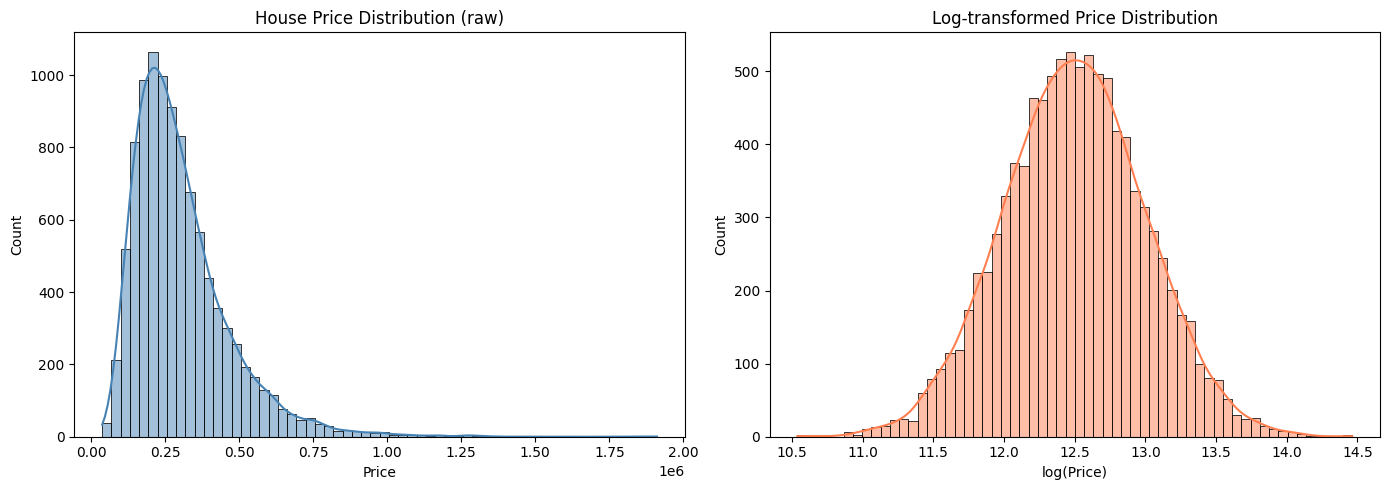

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution
sns.histplot(df['price'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('House Price Distribution (raw)')
axes[0].set_xlabel('Price')

# Log-transformed price
sns.histplot(np.log1p(df['price']), bins=60, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Log-transformed Price Distribution')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150)
plt.show()

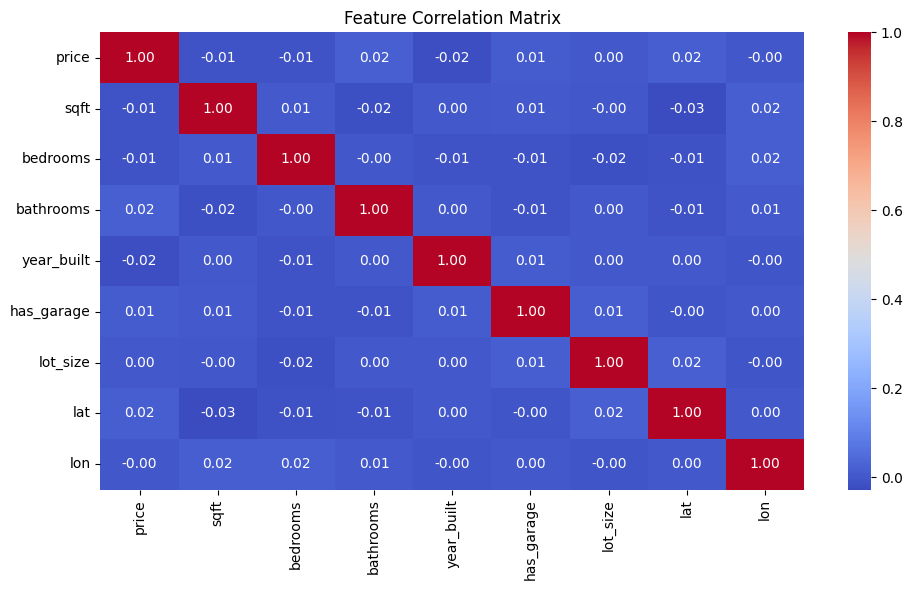

In [5]:
plt.figure(figsize=(10, 6))
num_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [6]:
from scipy import stats

before = len(df)
num_cols = ['price', 'sqft', 'lot_size']

z_scores = np.abs(stats.zscore(df[num_cols].fillna(df[num_cols].median())))
mask = (z_scores < 3).all(axis=1)
df = df[mask].reset_index(drop=True)

after = len(df)
print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Removed {before - after} outlier rows ({(before-after)/before*100:.1f}%)")


Rows before: 10,000
Rows after:  9,813
Removed 187 outlier rows (1.9%)


In [12]:
# Feature 1: Age of Home
df['age_of_home'] = 2024 - df['year_built']

# Feature 2: Price per square foot
df['price_per_sqft'] = df['price'] / df['sqft']

# Feature 3: Distance to city center (Haversine formula)
CITY_CENTER = {'lat': 18.9667, 'lon': 72.8333}

def haversine_km(lat, lon, clat, clon):
    R = 6371
    dlat = np.radians(lat - clat)
    dlon = np.radians(lon - clon)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat)) * \
        np.cos(np.radians(clat)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['dist_to_center_km'] = haversine_km(
    df['lat'], df['lon'],
    CITY_CENTER['lat'], CITY_CENTER['lon']
)

In [13]:
print("3 new features created!")
print(df[['age_of_home', 'price_per_sqft', 'dist_to_center_km']].describe().round(2))

3 new features created!
       age_of_home  price_per_sqft  dist_to_center_km
count      9813.00         9027.00            9813.00
mean         38.00          191.97              64.22
std          20.99          155.48              29.79
min           2.00           16.49               0.83
25%          20.00          102.07              40.95
50%          38.00          150.96              63.69
75%          56.00          232.04              88.86
max          74.00         2500.69             128.35


In [14]:
from sklearn.impute import KNNImputer

impute_cols = ['sqft', 'bathrooms', 'lot_size']

imputer = KNNImputer(n_neighbors=5)
df[impute_cols] = imputer.fit_transform(df[impute_cols])

print("Missing values after imputation:")
print(df.isnull().sum())
print("\nAll zeros = success!")

Missing values after imputation:
price                  0
sqft                   0
bedrooms               0
bathrooms              0
year_built             0
city                   0
has_garage             0
lot_size               0
lat                    0
lon                    0
age_of_home            0
price_per_sqft       786
dist_to_center_km      0
dtype: int64

All zeros = success!


In [15]:
# Recalculate price_per_sqft after imputation
df['price_per_sqft'] = df['price'] / df['sqft']

print("Missing values now:")
print(df.isnull().sum())
print("\nAll zeros = success!")


Missing values now:
price                0
sqft                 0
bedrooms             0
bathrooms            0
year_built           0
city                 0
has_garage           0
lot_size             0
lat                  0
lon                  0
age_of_home          0
price_per_sqft       0
dist_to_center_km    0
dtype: int64

All zeros = success!


In [16]:
df = pd.get_dummies(df, columns=['city'], drop_first=True, dtype=int)

print("Columns after encoding:")
print(df.columns.tolist())
print(f"\nFinal shape: {df.shape}")

Columns after encoding:
['price', 'sqft', 'bedrooms', 'bathrooms', 'year_built', 'has_garage', 'lot_size', 'lat', 'lon', 'age_of_home', 'price_per_sqft', 'dist_to_center_km', 'city_Delhi', 'city_Mumbai', 'city_Pune']

Final shape: (9813, 15)


In [17]:
import os

output_path = 'clean_real_estate.parquet'
df.to_parquet(output_path, index=False, engine='pyarrow', compression='snappy')

csv_size = os.path.getsize('enterprise_data.csv') / 1024
parquet_size = os.path.getsize(output_path) / 1024

print(f"CSV size:     {csv_size:.1f} KB")
print(f"Parquet size: {parquet_size:.1f} KB")
print(f"Compression:  {csv_size/parquet_size:.1f}x smaller")

df_verify = pd.read_parquet(output_path)
print(f"\nVerified: {df_verify.shape} loaded from parquet")
print("\nPipeline complete!")

CSV size:     1067.0 KB
Parquet size: 692.7 KB
Compression:  1.5x smaller

Verified: (9813, 15) loaded from parquet

Pipeline complete!
